# Домашнее задание: Анализ многомерных данных
## Неделя 10, Занятие 20: Снижение размерности

## 1. Введение

На этом занятии вы будете работать с методами снижения размерности (PCA и t-SNE). Ваша задача применить эти методы к реальному датасету, проанализировать результаты и сравнить их эффективность.

### Цель задания:
- Понять, как работает PCA и его ограничения
- Применить t-SNE для нелинейного снижения размерности
- Применить оба метода для визуализации данных
- Сравнить результаты и выбрать оптимальный метод
- Использовать результаты для улучшения кластеризации

## 2. Описание датасета

В этом задании вы работаете с датасетом MNIST (Modified National Institute of Standards and Technology Database) — классическим датасетом рукописных цифр.

**Характеристики:**
- **Объекты:** 1797 образцов рукописных цифр (0-9)
- **Признаки:** 64 (8×8 пиксели, значения 0-16)
- **Классы:** 10 (цифры от 0 до 9)
- **Размерность:** 64-мерное пространство

**Задача:** Применить методы снижения размерности, чтобы:
- Визуализировать данные в 2D
- Выявить структуру данных
- Улучшить кластеризацию

## 3. Загрузка и подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Загружаем датасет
digits = load_digits()
X = digits.data
y = digits.target

print(f"Датасет загружен")
print(f"Форма: {X.shape}")
print(f"Количество образцов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Количество классов: {len(np.unique(y))}")

Датасет загружен
Форма: (1797, 64)
Количество образцов: 1797
Количество признаков: 64
Количество классов: 10


## 4. Часть 1: Предварительный анализ данных

**Задания:**
1. Визуализируйте примеры из датасета
2. Посчитайте статистику по признакам
3. Проверьте распределение классов

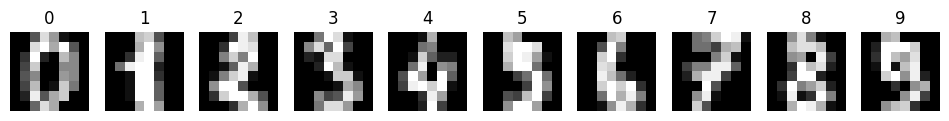

           0            1            2            3            4   \
count  1797.0  1797.000000  1797.000000  1797.000000  1797.000000   
mean      0.0     0.303840     5.204786    11.835838    11.848080   
std       0.0     0.907192     4.754826     4.248842     4.287388   
min       0.0     0.000000     0.000000     0.000000     0.000000   
25%       0.0     0.000000     1.000000    10.000000    10.000000   
50%       0.0     0.000000     4.000000    13.000000    13.000000   
75%       0.0     0.000000     9.000000    15.000000    15.000000   
max       0.0     8.000000    16.000000    16.000000    16.000000   

                5            6            7            8            9   ...  \
count  1797.000000  1797.000000  1797.000000  1797.000000  1797.000000  ...   
mean      5.781859     1.362270     0.129661     0.005565     1.993879  ...   
std       5.666418     3.325775     1.037383     0.094222     3.196160  ...   
min       0.000000     0.000000     0.000000     0.000000     

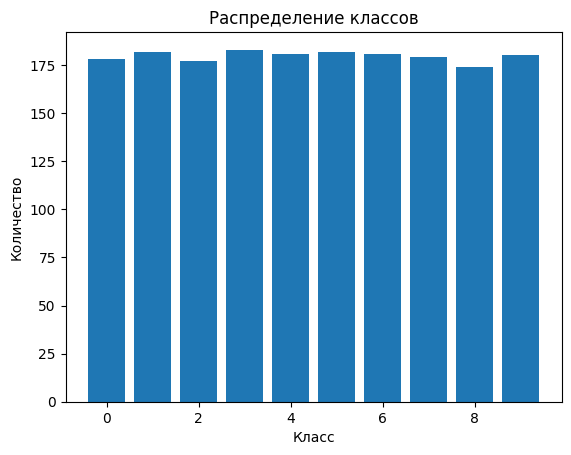

In [2]:
# Ваш код здесь
# 1. Визуализация примеров
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(str(y[i]))
    ax.axis('off')
plt.show()

# 2. Статистика
df = pd.DataFrame(X)
print(df.describe())

# 3. Распределение классов
unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.title("Распределение классов")
plt.show()

## 5. Часть 2: Стандартизация данных

In [3]:
# Стандартизируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Данные стандартизированы")
print(f"Среднее: {X_scaled.mean():.6f}")
print(f"Стандартное отклонение: {X_scaled.std():.6f}")

Данные стандартизированы
Среднее: 0.000000
Стандартное отклонение: 0.976281


## 6. Часть 3: PCA (Principal Component Analysis)

**Задания:**
1. Вычислите объясненную дисперсию для каждой компоненты
2. Постройте график кумулятивной дисперсии
3. Определите, сколько компонент нужно для 95% и 99% дисперсии
4. Примените PCA для 2D визуализации
5. Визуализируйте результаты

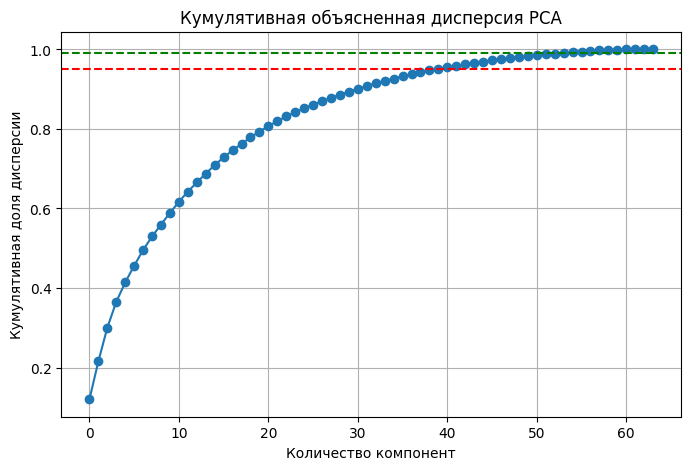

Для 95%: 40 компонент
Для 99%: 54 компонент


In [4]:
# 1. Полный PCA анализ
pca_full = PCA()
pca_full.fit(X_scaled)

# 2. График кумулятивной дисперсии
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Ваш код здесь: постройте график
plt.figure(figsize=(8, 5))
plt.plot(cumsum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--')
plt.axhline(0.99, color='g', linestyle='--')
plt.xlabel("Количество компонент")
plt.ylabel("Кумулятивная доля дисперсии")
plt.title("Кумулятивная объясненная дисперсия PCA")
plt.grid()
plt.show()

# 3. Найти количество компонент
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_99 = np.argmax(cumsum_var >= 0.99) + 1

print(f"Для 95%: {n_components_95} компонент")
print(f"Для 99%: {n_components_99} компонент")

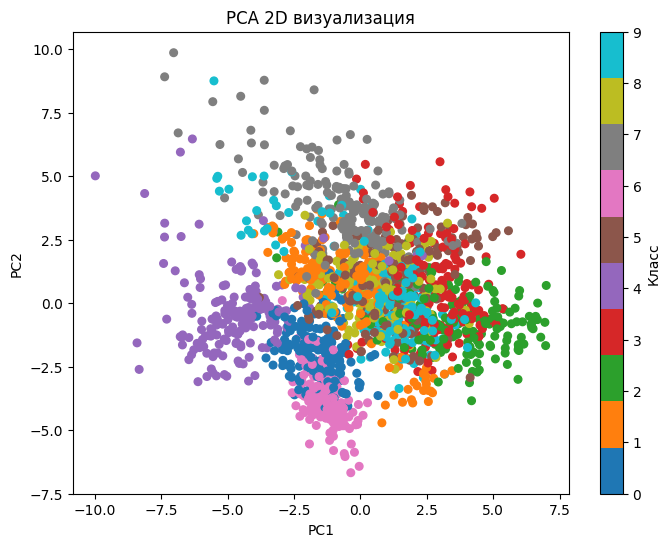

Объясненная дисперсия: 21.59%


In [5]:
# 4. PCA 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 5. Визуализация
# Ваш код здесь: scatter plot с метками y
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', s=30)
plt.colorbar(label='Класс')
plt.title("PCA 2D визуализация")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print(f"Объясненная дисперсия: {pca_2d.explained_variance_ratio_.sum():.2%}")

## 7. Часть 4: t-SNE (t-Distributed Stochastic Neighbor Embedding)

**Задания:**
1. Примените PCA 50D (предварительное снижение размерности)
2. Примените t-SNE к PCA 50D
3. Визуализируйте результаты
4. Экспериментируйте с параметром perplexity

In [6]:
# 1. PCA 50D
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_scaled)

print(f"PCA 50D: объясненная дисперсия {pca_50.explained_variance_ratio_.sum():.2%}")

PCA 50D: объясненная дисперсия 98.28%


Применяю t-SNE... (может занять минуту)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Готово!


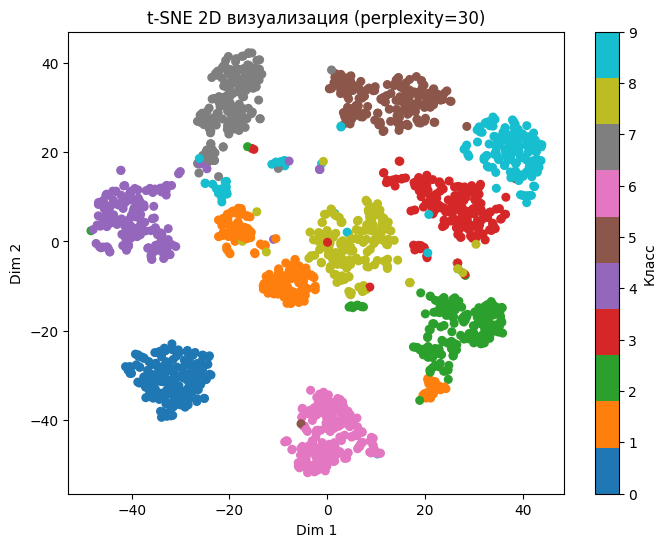

In [7]:
# 2. t-SNE
print("Применяю t-SNE... (может занять минуту)")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca_50)
print("Готово!")

# 3. Визуализация
# Ваш код здесь: scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=30)
plt.colorbar(label='Класс')
plt.title("t-SNE 2D визуализация (perplexity=30)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


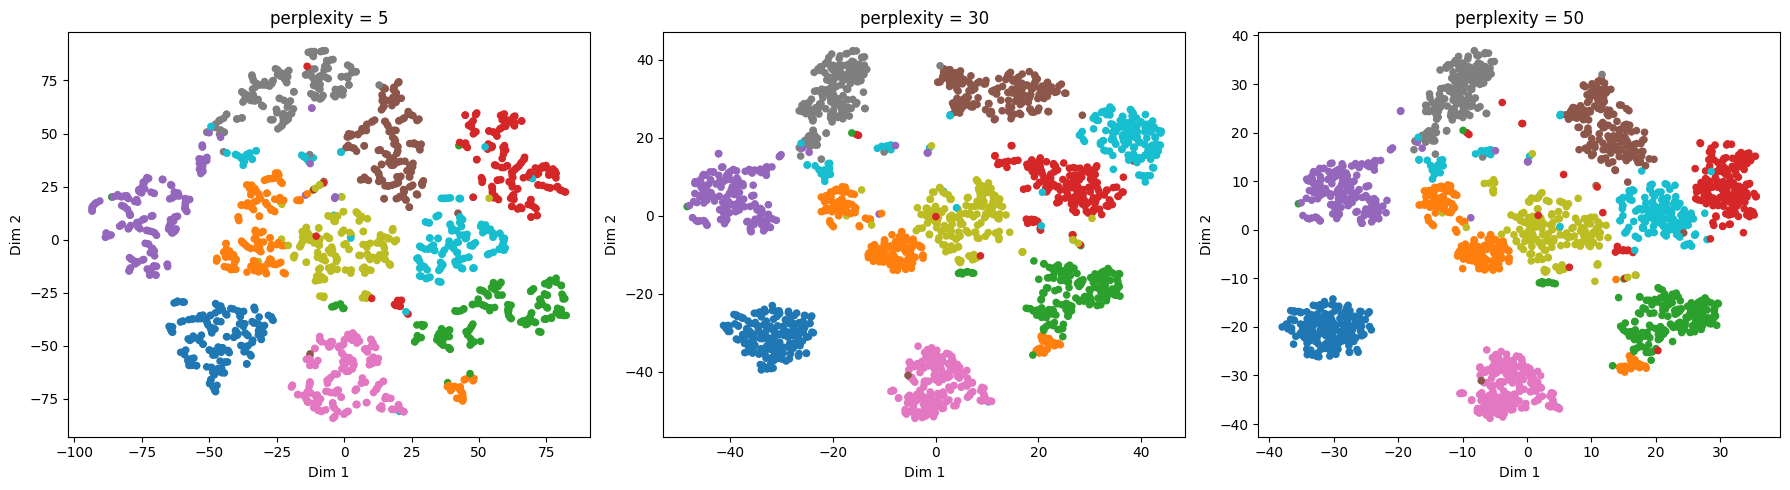

In [8]:
# 4. Эксперименты с perplexity
perplexities = [5, 30, 50]

# Ваш код здесь: примените t-SNE с разными perplexity
# и визуализируйте результаты
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, p in zip(axes, perplexities):
    tsne_tmp = TSNE(n_components=2, perplexity=p, n_iter=1000, random_state=42)
    X_tsne_tmp = tsne_tmp.fit_transform(X_pca_50)
    ax.scatter(X_tsne_tmp[:, 0], X_tsne_tmp[:, 1], c=y, cmap='tab10', s=20)
    ax.set_title(f"perplexity = {p}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

# Какое значение выглядит оптимальным? - 30

## 8. Часть 5: Сравнение методов

**Задания:**
1. Визуализируйте результаты PCA и t-SNE рядом
2. Сравните время выполнения
3. Напишите вывод о различиях

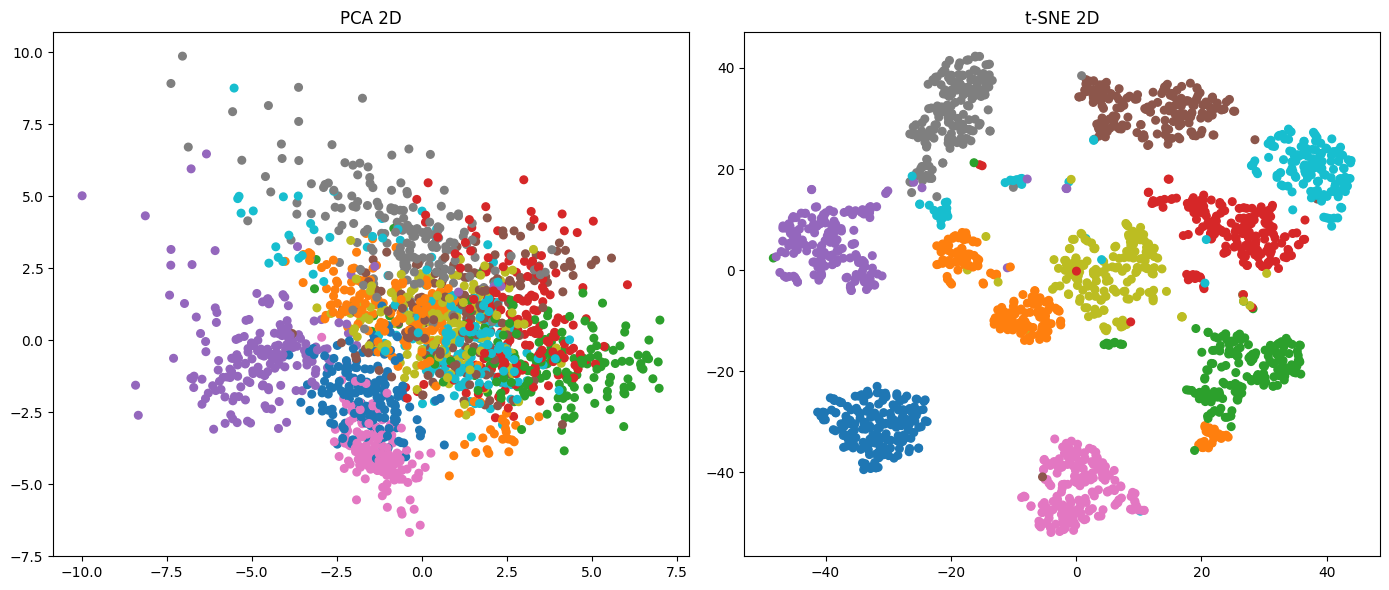

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Время PCA: 0.051 сек
Время t-SNE: 15.381 сек
t-SNE медленнее в 300.9 раз


In [9]:
# 1. Сравнение визуализаций
# Создайте subplot с двумя графиками: PCA и t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', s=30)
axes[0].set_title("PCA 2D")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=30)
axes[1].set_title("t-SNE 2D")

plt.tight_layout()
plt.show()

# 2. Время выполнения
import time

# Измерьте время для PCA
t_start = time.time()
_ = PCA(n_components=2).fit_transform(X_scaled)
t_pca = time.time() - t_start

# Измерьте время для t-SNE
t_start = time.time()
_ = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42).fit_transform(X_pca_50)
t_tsne = time.time() - t_start

print(f"Время PCA: {t_pca:.3f} сек")
print(f"Время t-SNE: {t_tsne:.3f} сек")
print(f"t-SNE медленнее в {t_tsne/t_pca:.1f} раз")

## 9. Часть 6: Применение для кластеризации

**Задания:**
1. Примените K-Means к исходным данным
2. Примените K-Means к PCA проекции
3. Примените K-Means к t-SNE проекции
4. Сравните качество (silhouette score)
5. Визуализируйте результаты

In [10]:
# K-Means на разных данных
kmeans_original = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_original = kmeans_original.fit_predict(X_scaled)

kmeans_pca = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca_50)

kmeans_tsne = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_tsne = kmeans_tsne.fit_predict(X_tsne)

# Силуэтные коэффициенты
score_original = silhouette_score(X_scaled, labels_original)
score_pca = silhouette_score(X_pca_50, labels_pca)
score_tsne = silhouette_score(X_tsne, labels_tsne)

print(f"Silhouette Score (исходные): {score_original:.3f}")
print(f"Silhouette Score (PCA 50D): {score_pca:.3f}")
print(f"Silhouette Score (t-SNE 2D): {score_tsne:.3f}")

Silhouette Score (исходные): 0.139
Silhouette Score (PCA 50D): 0.151
Silhouette Score (t-SNE 2D): 0.573


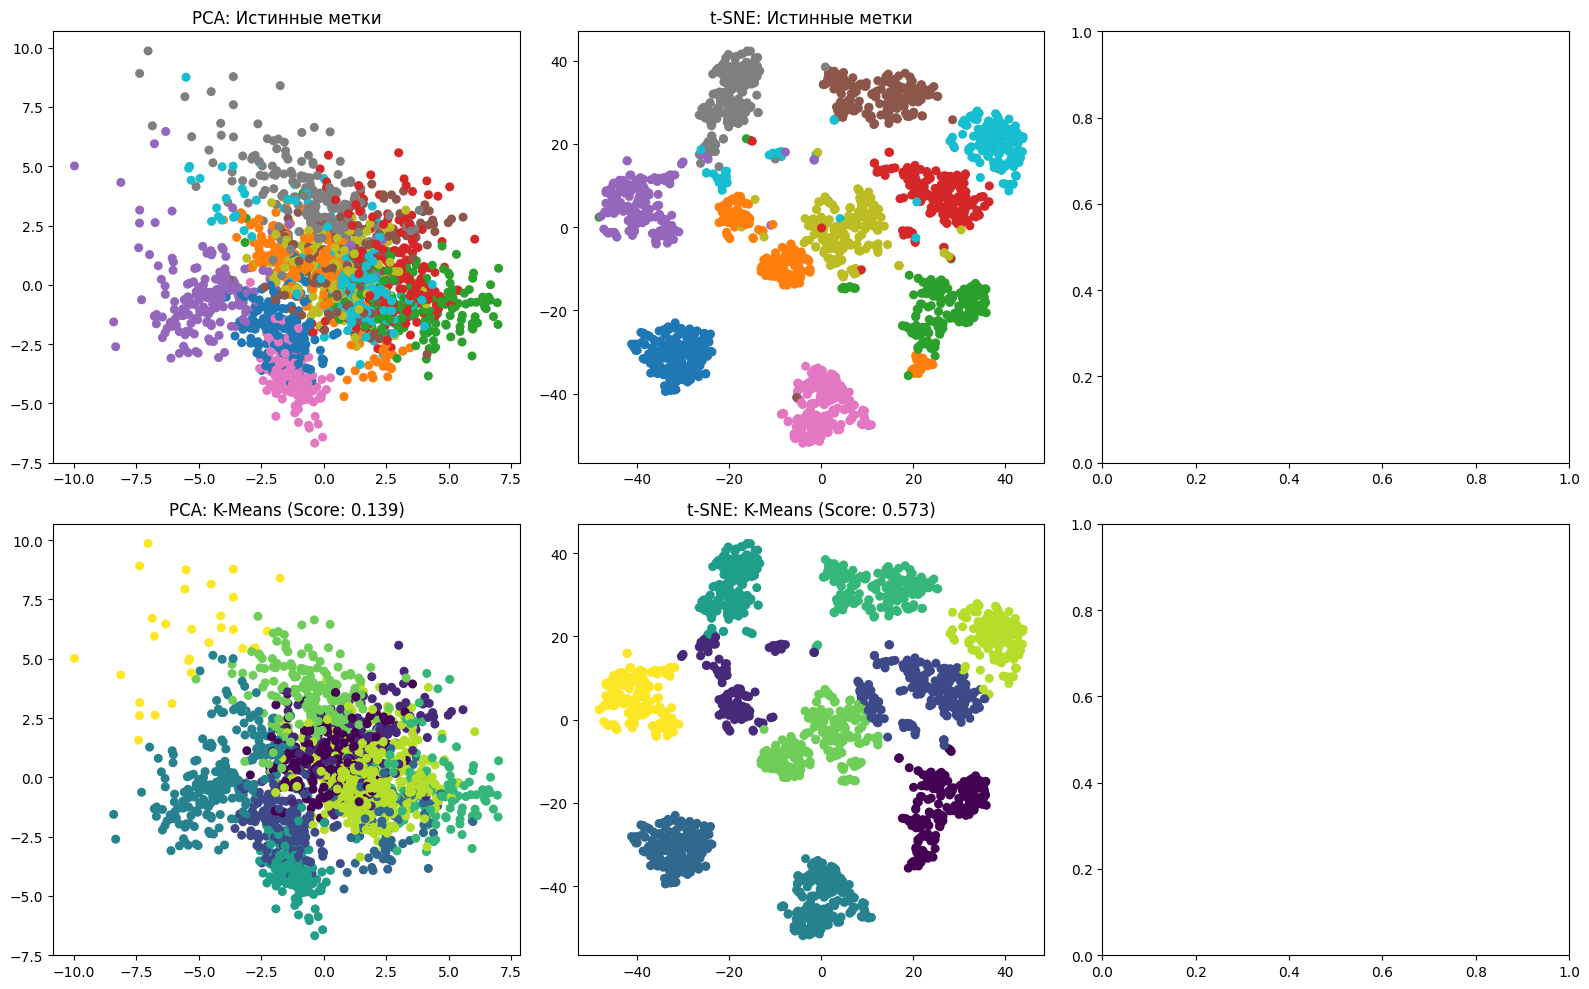

In [11]:
# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Истинные метки
scatter1 = axes[0, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', s=30)
axes[0, 0].set_title('PCA: Истинные метки')

scatter2 = axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=30)
axes[0, 1].set_title('t-SNE: Истинные метки')

# Предсказанные кластеры
scatter3 = axes[1, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_original, cmap='viridis', s=30)
axes[1, 0].set_title(f'PCA: K-Means (Score: {score_original:.3f})')

scatter4 = axes[1, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_tsne, cmap='viridis', s=30)
axes[1, 1].set_title(f't-SNE: K-Means (Score: {score_tsne:.3f})')

plt.tight_layout()
plt.show()

## 10. Анализ результатов

**Напишите анализ:**

1. **Объясненная дисперсия:** Какой процент информации теряется при снижении с 64D до 2D?

2. **Сравнение методов:** Какой метод лучше сохраняет структуру данных?

3. **Кластеризация:** Как снижение размерности влияет на качество кластеризации?

4. **Практическое применение:** Когда использовать PCA, когда t-SNE?

5. **Проблемы и ограничения:** Какие недостатки каждого метода вы выявили?

### Ваш анализ:

1. При сжатии теряется примерно 75% дисперсии
2. t-SNE учше разделяет данные
3. Кластеризация становится четче, так как удаляется лишний шум
4. PCA лучше использовать для сжатия данных, ускорения моделей и подготовки признаков для обучения, а t-SNE использовать для визуализации и анализа данных
5. PCA ограничен линейностью и может терять важную нелинейную структуру, а t-SNE чувствителен к параметрам и плохо масштабируется, вычисляется долго